# Code Assignment 17 — K-Means Model Comparison with CH & DB + Assumption Testing (Mall Customers)

**Format:** Instructor Guidance → Your Task (step-by-step) → We Share (reflection)

**Goal:**  Compare **two feature sets** for K-Means at the **same K**:  
- **Model 1:** 2 features → `['Annual Income (k$)', 'Spending Score (1-100)']`  
- **Model 2:** 3 features → `['Age', 'Annual Income (k$)', 'Spending Score (1-100)']`  
Evaluate with **Silhouette (↑), Calinski–Harabasz (↑), Davies–Bouldin (↓)**, **separation ratio** (↑), **cluster sizes**, and **stability (median ARI) (↑)**.



## Instructor Guidance (Pseudocode + Docs)

**Docs**  
- `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html  
- `KMeans`: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html  
- `silhouette_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html  
- `calinski_harabasz_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.calinski_harabasz_score.html  
- `davies_bouldin_score`: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.davies_bouldin_score.html  
- `adjusted_rand_score` (stability): https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html

### Pseudocode Plan (Model Comparison)
  1) Load CSV → pick clean numeric columns (2D vs 3D).  
  2) **Scale** each feature set **separately** with `StandardScaler`.  
  3) Fix **K** (e.g., K=4).  
  4) Fit KMeans on each set → get labels & centers.  
  5) Compute metrics: `silhouette_score` (↑), `calinski_harabasz_score` (↑), `davies_bouldin_score` (↓).  
  6) Assumption checks: **separation ratio** (min between-centroid distance ÷ max within-cluster spread), **cluster sizes** (%), **stability via ARI** across seeds.  
  7) Compare models in a table → pick one and justify.


## Your Task — Step-by-Step
Work in pairs. Keep it minimal and clear.

### 0) Run Helper Functions and do your Imports

In [1]:
# RUN THIS CELL WITHOUT CHANGES 

def cluster_size_pct(labels):
    """Return % size of each cluster (sorted by cluster index)."""
    s = pd.Series(labels).value_counts(normalize=True).sort_index()
    return (s * 100).round(1)

def within_between_ratio(Z, labels, centers):
    """
    Heuristic separation metric:
    min distance among centroids ÷ max within-cluster spread (avg feature std per cluster).
    Higher is better (more separated vs within spread).
    """
    within = []
    for c in range(centers.shape[0]):
        pts = Z[labels == c]
        if len(pts) == 0:
            within.append(np.nan)
        else:
            within.append(pts.std(axis=0).mean())
    within = np.array(within, dtype=float)
    max_within = np.nanmax(within)

    D = cdist(centers, centers)  # centroid distance matrix
    np.fill_diagonal(D, np.nan)
    min_between = np.nanmin(D)
    return float(min_between / max_within)

def stability_ari(Z, k, seeds=(0, 1, 2, 3, 4)):
    """
    Fit KMeans across multiple seeds and compute median Adjusted Rand Index across pairs.
    Higher median ARI = more stable clustering to initialization.
    """
    label_sets = []
    for s in seeds:
        km = KMeans(n_clusters=k, n_init=10, random_state=s).fit(Z)
        label_sets.append(km.labels_)
    pairs = [(i, j) for i in range(len(label_sets)) for j in range(i+1, len(label_sets))]
    aris = [adjusted_rand_score(label_sets[i], label_sets[j]) for (i, j) in pairs]
    return float(np.median(aris))


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### 1) Load the Mall Customers CSV & Preview
Use the same dataset as last time.

In [3]:
df = pd.read_csv("/Users/Marcy_Student/Downloads/Mall_Customers copy.csv")
display(df.shape)
display(df.head())

(200, 5)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 2) Build 2D and 3D feature sets (numeric only, minimal cleaning)

- 2D set:  Annual Income and Spending Score
- 3D set:  Age, Annual Income, Spending Score 

**Be sure to scale!**


In [21]:
# 2D model features
X2D = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 3D model features
X3D = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scale each separately
Z2 = StandardScaler().fit_transform(X2D)

Z3 = StandardScaler().fit_transform(X3D)


### 3) Choose a single k for BOTH models (you can try 3, 4, 5, etc.)

In [22]:
K_FIXED = 5
print('Using K =', K_FIXED)

Using K = 5


### 4) Fit Model 1 (2D @ K) and compute metrics

- No train-test split needed 
- Use helper functions above to help calculate metrics!


In [23]:
km2 = KMeans(n_clusters=K_FIXED, n_init=10, random_state=0).fit(Z2)
labels2 = km2.labels_
centers2 = km2.cluster_centers_

# Metrics

sil2 = silhouette_score(Z2, labels2)
ch2  = calinski_harabasz_score(Z2, labels2)
db2  = davies_bouldin_score(Z2, labels2)
sep2 = within_between_ratio(Z2, labels2, centers2)
size2 = cluster_size_pct(labels2)
stab2 = stability_ari(Z2, K_FIXED)

print("Model 1 (2D) Metrics:")
print("Silhouette:", sil2)
print("Calinski–Harabasz:", ch2)
print("Davies–Bouldin:", db2)
print("Separation ratio:", sep2)
print("Stability ARI:", stab2)
print("Cluster sizes (%):\n", size2)


Model 1 (2D) Metrics:
Silhouette: 0.5546571631111091
Calinski–Harabasz: 248.64932001536357
Davies–Bouldin: 0.5722356162263352
Separation ratio: 3.1425974906339635
Stability ARI: 1.0
Cluster sizes (%):
 0   40.5000
1   19.5000
2   17.5000
3   11.5000
4   11.0000
Name: proportion, dtype: float64


### 5) Fit Model 2 (3D @ K) and compute metrics

- No train-test split needed 
- Use helper functions above to help calculate metrics!
- Use same k as Model 1

In [24]:
km3 = KMeans(n_clusters=K_FIXED, n_init=10, random_state=0).fit(Z3)
labels3 = km3.labels_
centers3 = km3.cluster_centers_

# Metrics

sil3 = silhouette_score(Z3, labels3)
ch3  = calinski_harabasz_score(Z3, labels3)
db3  = davies_bouldin_score(Z3, labels3)
sep3 = within_between_ratio(Z3, labels3, centers3)
size3 = cluster_size_pct(labels3)
stab3 = stability_ari(Z3, K_FIXED)

print("Model 2 (3D) Metrics:")
print("Silhouette:", sil3)
print("Calinski–Harabasz:", ch3)
print("Davies–Bouldin:", db3)
print("Separation ratio:", sep3)
print("Stability ARI:", stab3)
print("Cluster sizes (%):\n", size3)


Model 2 (3D) Metrics:
Silhouette: 0.41664341513732767
Calinski–Harabasz: 125.10094020060956
Davies–Bouldin: 0.874551051002418
Separation ratio: 2.794037048691251
Stability ARI: 1.0
Cluster sizes (%):
 0   23.5000
1   19.5000
2   20.0000
3   10.0000
4   27.0000
Name: proportion, dtype: float64


### 6) Visualize Model 1 (2D Scatter Plot)


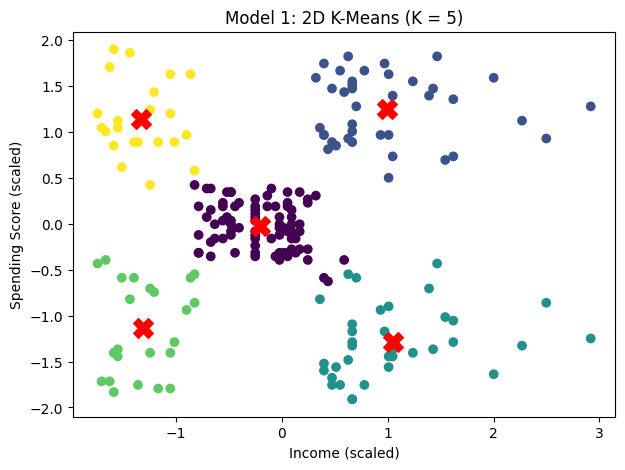

In [25]:

plt.figure(figsize=(7,5))
plt.scatter(Z2[:,0], Z2[:,1], c=labels2, cmap='viridis')
plt.scatter(centers2[:,0], centers2[:,1], c='red', s=200, marker='X')
plt.xlabel("Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Model 1: 2D K-Means (K = %d)" % K_FIXED)
plt.show()


## We Share — Reflection (short, specific)
1) **Which model is better and why?** Reference **Sil (↑), CH (↑), DB (↓)**, **separation ratio (↑)**, **stability ARI (↑)**, and **cluster sizes**.  

2) **Assumptions & ethics:** Did your chosen model show **non-overlapping, roughly spherical, similarly dense** clusters? If not, what risk could that pose to stakeholders (mis-targeted offers, unfair treatment)?  
3) **Next step:** If you had to ship this, what monitoring would you add (e.g., re-check metrics quarterly, watch for tiny cluster drift, re-scale after schema changes)?

> Tip: If metrics conflict (e.g., CH prefers K=6, DB prefers K=4), prefer **parsimonious K** with **clear separation**, **stable labels**, and **business actionability**.


Using K-Means with 5 clusters, the 2D model using Annual Income and Spending Score performed much better than the 3D model that included Age, for all metrics. A higher silhouette score (0.55 vs. 0.42), a much higher Calinski Harabasz score (248.65 vs. 125.10), a lower Davies Bouldin score (0.57 vs. 0.87), and a better separation ratio (3.14 vs. 2.79). Displaying tighter clusters that are clearer and more separated. These results also mean the 2D model aligns better with KMeans’ assumptions of having round, well-separated clusters, reducing the risk of misgrouping customers, which could then lead to inconsistent or unfair marketing offers, especially if age-driven clusters become messy or overlapping. If this model were deployed, it would be important to monitor it over time by checking silhouette, CH, and DB scores quarterly, keeping an eye on cluster sizes so tiny unstable clusters don’t appear, watching for centroid drift that signals changing customer behavior.